# Exploring Latent Space

```python
class Encoder:
    ...
    
    def __call__(self, x: Tensor) -> Tensor:
        ...
        x = self.linear(x.flatten(start_dim=1)) # (bs, 16)
        return x 

```
> We are encoding the image into 16 values which is good size for 10 classes. \
> But we can see that our model aproching minimum pretty easy around (1000th step) \
> We can push the compresion even further and see how model handles that.

In [1]:
import matplotlib.pyplot as plt
plt.set_cmap('gray_r')

from tinygrad.helpers import Context, trange
from tinygrad import Tensor, Device , GlobalCounters, nn, TinyJit
from tinygrad.nn.datasets import mnist

print(f"Default device: {Device.DEFAULT}")
X_train, Y_train, X_test, Y_test = mnist()
X_train = X_train.div(255.0)
X_test = X_test.div(255.0)

print(X_train.shape, X_train.dtype, Y_train.shape, Y_train.dtype);

Default device: AMD
(60000, 1, 28, 28) dtypes.float (60000,) dtypes.uchar


<Figure size 640x480 with 0 Axes>

In [2]:
class conv_block:
    def __init__(self,
        in_channels: int,
        out_channels: int,
        kernel_size: int = 4,
        stride: int = 2,
        padding: int = 1):
        
        
        self.conv= nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding)
        self.norm = nn.BatchNorm2d(out_channels)
    
    def __call__(self,x:Tensor) -> Tensor:
        x = self.conv(x)
        x = self.norm(x)
        return x.relu()
    

class Encoder:
    def __init__(self, in_channels, latent_dims: int):
        self.conv1 = conv_block(in_channels, 128)
        self.conv2 = conv_block(128,256)
        self.conv3 = conv_block(256,512)
        self.conv4 = conv_block(512,1024)
        self.linear = nn.Linear(1024, latent_dims)
    
    def __call__(self, x: Tensor) -> Tensor:    # (bs, 1, 28 , 28)
        x = self.conv1(x)                       # (bs, 128, 14 ,14)
        x = self.conv2(x)                       # (bs, 256, 7 ,7)
        x = self.conv3(x)                       # (bs, 512, 3 ,3)
        x = self.conv4(x)                       # (bs, 1024, 1 ,1)
        x = self.linear(x.flatten(start_dim=1)) # (bs, latent_dims)
        return x

class conv_transpose_block:
    def __init__(self,
        in_channels: int,
        out_channels: int,
        kernel_size: int = 3,
        stride: int = 2,
        padding: int = 1,
        output_padding: int = 0,
        with_act: bool = True):
        self.t_conv = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size,
            stride,
            padding,
            output_padding
        )
        if with_act:
            self.norm = nn.BatchNorm2d(out_channels)
 
    def __call__(self, x: Tensor) -> Tensor:
        x = self.t_conv(x)
        if hasattr(self, 'norm'):
            x = self.norm(x)
            return x.relu()
        return x

class Decoder():
    def __init__(self, out_channels: int, latent_dims:int):
        self.linear = nn.Linear(latent_dims, 1024 * 4 * 4)
        self.t_conv1 = conv_transpose_block(1024, 512)
        self.t_conv2 = conv_transpose_block(512, 256, output_padding=1)
        self.t_conv3 = conv_transpose_block(256, out_channels, output_padding=1, with_act=False)
    def __call__(self, x:Tensor) -> Tensor:
        bs = x.shape[0]
        x = self.linear(x)              #(bs, 1024 *4 *4)
        x = x.reshape((bs, 1024, 4, 4)) #(bs, 1024, 4, 4)
        x = self.t_conv1(x)             #(bs, 512, 7, 7)
        x = self.t_conv2(x)             #(bs, 256, 14, 14)
        x = self.t_conv3(x)             #(bs, out_channels, 28, 28)
        
        return x.sigmoid()              # Added sigmoid to squeeze values between (0,1)
    
class AutoEncoder():
    def __init__(self, in_channels, latent_dims):
        self.encoder = Encoder(in_channels,latent_dims)
        self.decoder = Decoder(in_channels,latent_dims)
    
    def encode(self, x: Tensor) -> Tensor:
        return self.encoder(x)
    
    def decode(self, x:Tensor) -> Tensor:
        return self.decoder(x)
    
    def __call__(self, x:Tensor) -> Tensor:
        return self.decode(self.encode(x))



In [3]:
model = AutoEncoder(1,2)
batch_size = 64
epochs = 10
lr = 1e-4
optim = nn.optim.AdamW(nn.state.get_parameters(model), lr=lr, eps=1e-5)

losses = []

def mean_squared_error(self, Y: Tensor, reduction: str = "mean") -> Tensor:
    return self.sub(Y).pow(2)._do_reduction(reduction)

Tensor.mean_squared_error = mean_squared_error  # type: ignore

@Tensor.train()
@TinyJit
def train_step():
    optim.zero_grad()
    samples = Tensor.randint(batch_size, high=X_train.shape[0])
    X = X_train[samples]
    preds = model(X)
    loss = preds.mean_squared_error(X)
    loss.backward()
    optim.step()
    return loss.realize()

In [4]:
# Calculate step_size
step_size = len(X_train) // batch_size
epochs = 10

if __name__ == "__main__":
# Modified training loop to use trange
    with Context(BEAM=2):
        for step in (t := trange(epochs * step_size)):
            GlobalCounters.reset()
            loss = train_step()
            loss_item = loss.item()
            losses.append(loss_item)
            t.set_description(f"loss: {loss_item:6.4f}")

loss: 0.0396: 100%|█████████████████████████| 9370/9370 [02:29<00:00, 62.54it/s]


9370 0.030271004885435104


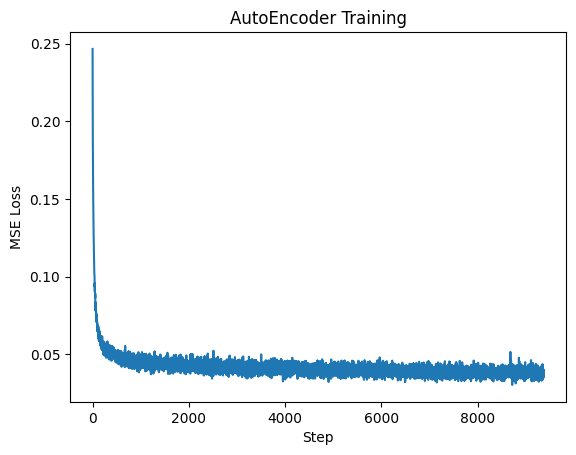

In [5]:
print(len(losses), min(losses))
# --- Plotting ---
plt.plot(losses)
plt.xlabel("Step")
plt.ylabel("MSE Loss")
plt.title("AutoEncoder Training")
plt.show()

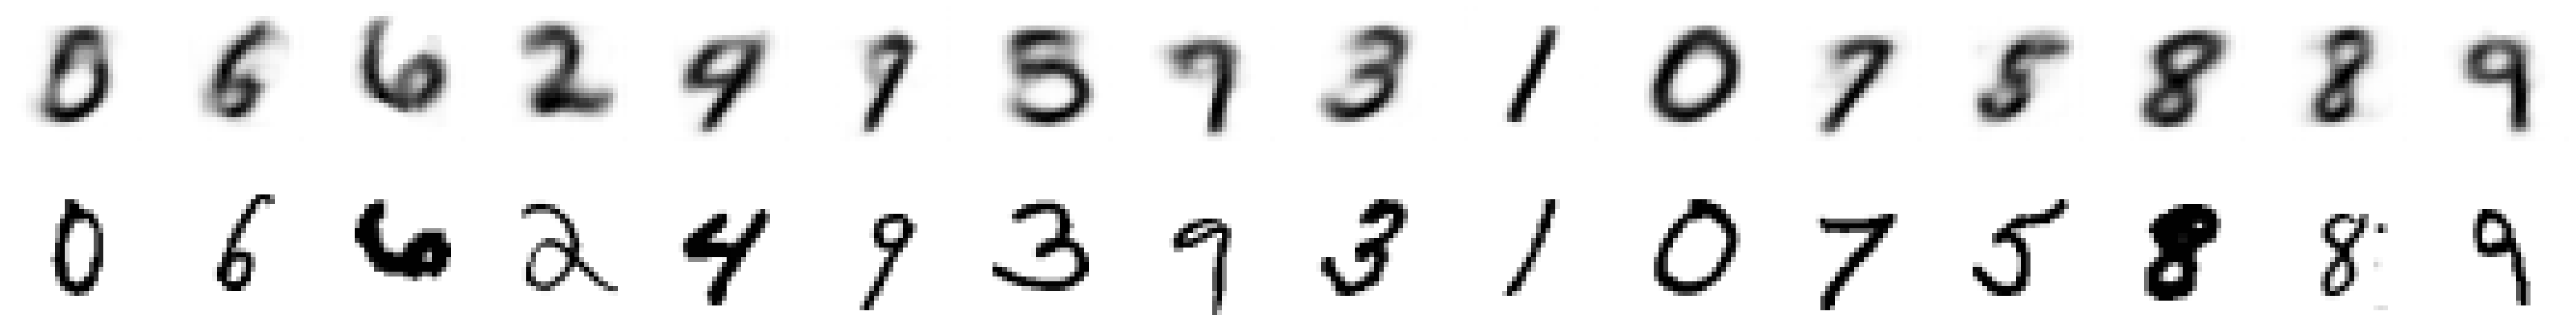

In [6]:

from afterhours_papers.helpers import show_images
# Example usage
sample_size = 16
samples = Tensor.randint(sample_size, high=X_train.shape[0])
batch = X_train[samples]

out = model(batch)
batch_vs_preds = out.cat(batch, dim=0)

images = batch_vs_preds.reshape(sample_size*2 ,28 ,28).numpy()
# Display using the show_images function
show_images(
    images,
    nrows=2,
    ncols=sample_size,
);

# Visualizing the Latent Space

We can represent all the encoded vectors from the test dataset.

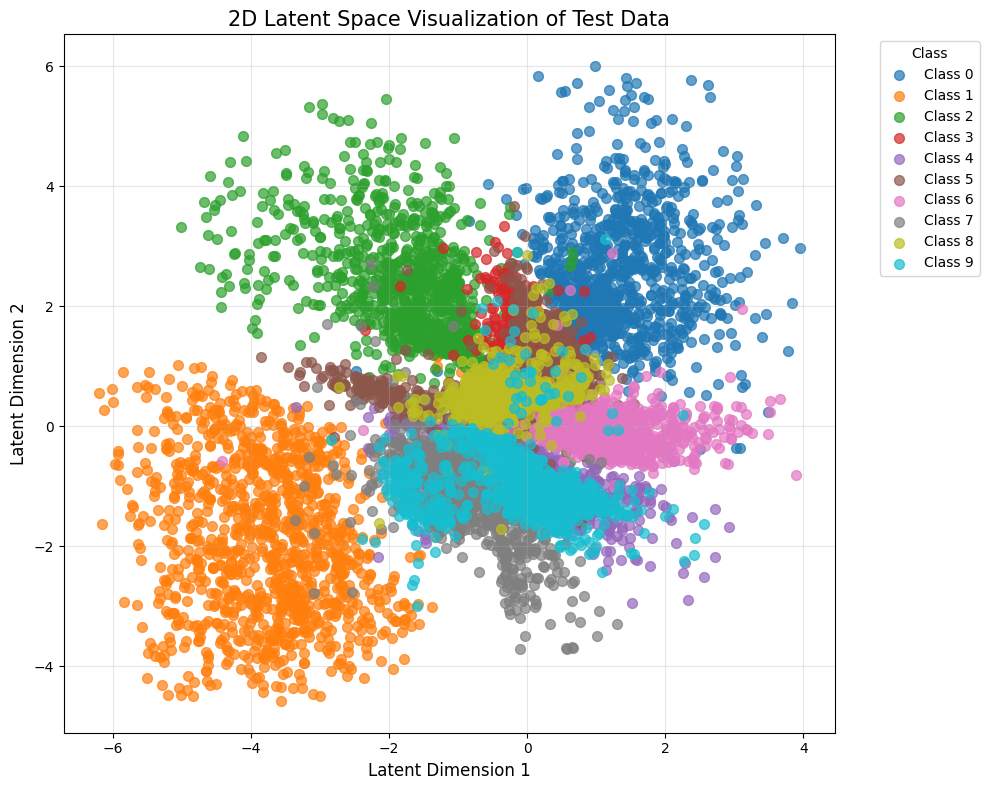

In [7]:
# Dictionary to store the encoded features and labels
encoded_data = {'x': [], 'y': [], 'label': []}

# Process X_test using tensor split functionality
batch_size = 1024
batches = X_test.split(1024)  # Split X_test into batches of 128 elements

for batch_idx, batch in enumerate(batches):
    # Calculate start index for this batch
    start_idx = batch_idx * 1024
    
    # Encode the batch using model
    encoded_batch = model.encode(batch)
    
    # Store the encoded values and corresponding labels
    batch_size = batch.shape[0]  # Get actual batch size (might be smaller for the last batch)
    
    # Extract batch data efficiently
    encoded_data['x'].extend(encoded_batch[:, 0].numpy())  # First dimension as x
    encoded_data['y'].extend(encoded_batch[:, 1].numpy())  # Second dimension as y
    
    # Get the corresponding labels for this batch
    batch_labels = Y_test[start_idx:start_idx+batch_size].numpy()
    encoded_data['label'].extend(batch_labels)

# Create a DataFrame for easier plotting
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.DataFrame(encoded_data)

# Create a scatter plot using matplotlib directly
plt.figure(figsize=(10, 8))

# Get unique labels and assign colors
unique_labels = np.unique(df['label'])
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

# Plot each class with a different color
for i, label in enumerate(unique_labels):
    mask = df['label'] == label
    plt.scatter(
        df.loc[mask, 'x'], 
        df.loc[mask, 'y'],
        color=colors[i],
        label=f'Class {label}',
        alpha=0.7,
        s=50  # Point size
    )

# Add a title and labels
plt.title('2D Latent Space Visualization of Test Data', fontsize=15)
plt.xlabel('Latent Dimension 1', fontsize=12)
plt.ylabel('Latent Dimension 2', fontsize=12)

# Add a legend
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')

# Improve the plot appearance
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()